In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lobster5 import *
import gc

Found 23 trading days.
Processing 2013-09-30 ...
Processing 2013-10-01 ...
Processing 2013-10-02 ...
Processing 2013-10-03 ...
Processing 2013-10-04 ...
Processing 2013-10-07 ...
Processing 2013-10-08 ...
Processing 2013-10-09 ...
Processing 2013-10-10 ...
Processing 2013-10-11 ...
Processing 2013-10-14 ...
Processing 2013-10-15 ...
Processing 2013-10-16 ...
Processing 2013-10-17 ...
Processing 2013-10-18 ...
Processing 2013-10-21 ...
Processing 2013-10-22 ...
Processing 2013-10-23 ...
Processing 2013-10-24 ...
Processing 2013-10-25 ...
Processing 2013-10-28 ...
Processing 2013-10-29 ...
Processing 2013-10-30 ...


/Users/thibaultmarty/miniconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


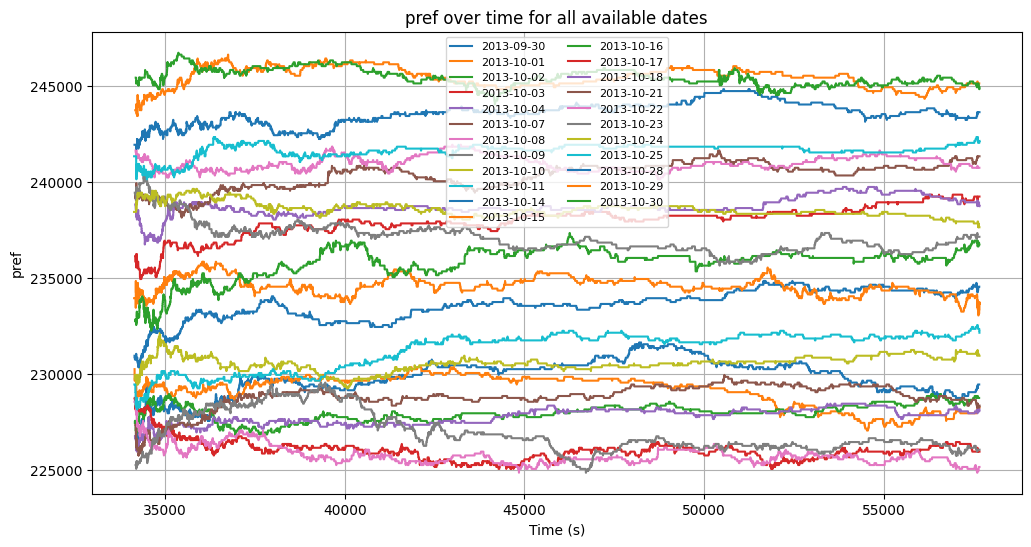

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import gc

# ── 1. Configuration & Variables ──────────────────────────────────────────────
PRIMARY = "INTC"
START_DATE = "2013-09-30"
END_DATE = "2013-10-30"
LEVELS = 5
K = 5
MARKET_OPEN_S  = 34140
MARKET_CLOSE_S = 57660

DATA_DIR = Path("data2")
stock_folder = DATA_DIR / f"{PRIMARY}_{START_DATE}_{END_DATE}_{LEVELS}"

msg_files = sorted(stock_folder.glob(f"*message_{LEVELS}.csv"))

if not msg_files:
    raise FileNotFoundError(f"No message files found in {stock_folder}")

print(f"Found {len(msg_files)} trading days.")

# ── 2. Loop over all available dates ──────────────────────────────────────────
pref_series_list = []

for msg_path in msg_files:
    parts = msg_path.stem.split("_")
    current_date = parts[1]

    ob_name = msg_path.name.replace("_message_", "_orderbook_")
    ob_path = stock_folder / ob_name

    if not ob_path.exists():
        print(f"Skipping {current_date}: missing orderbook file")
        continue

    print(f"Processing {current_date} ...")

    msg, ob, qr, df = load_lobster_data(
        str(msg_path),
        str(ob_path),
        levels=LEVELS,
        K=K,
        market_open_seconds=MARKET_OPEN_S
    )

    table = make_descriptive_table(df, K=5)
    aes = compute_aes_by_level(df, K=5, lvl_col="lvl", size_col="size")
    df = normalize_by_aes(df, aes=aes, K=5)

    pref_df = df[["time", "pref"]].copy()
    pref_df["date"] = current_date
    pref_series_list.append(pref_df)

    del msg, ob, qr, df, table, aes
    gc.collect()

# ── 3. Plot all pref series on one graph ──────────────────────────────────────
plt.figure(figsize=(12, 6))

for pref_df in pref_series_list:
    date_label = pref_df["date"].iloc[0]
    plt.plot(pref_df["time"], pref_df["pref"], label=date_label)

plt.xlabel("Time (s)")
plt.ylabel("pref")
plt.title("pref over time for all available dates")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.show()

In [9]:
results = []

for pref_df in pref_series_list:
    r = np.diff(pref_df["pref"].values)
    
    rv = np.sum(r**2)
    vol = np.std(r)
    
    results.append({
        "date": pref_df["date"].iloc[0],
        "rv": rv,
        "vol": vol
    })

df_vol = pd.DataFrame(results).sort_values("rv", ascending=False)
print(df_vol)

          date          rv       vol
11  2013-10-15  11210000.0  4.435618
0   2013-09-30  10210000.0  4.132664
12  2013-10-16   9440000.0  4.690094
7   2013-10-09   8920000.0  3.684270
3   2013-10-03   8680000.0  3.925622
6   2013-10-08   8300000.0  3.653229
22  2013-10-30   7010000.0  4.065688
20  2013-10-28   6950000.0  4.054565
17  2013-10-23   6810000.0  3.883576
8   2013-10-10   6720000.0  3.946263
1   2013-10-01   5980000.0  3.840554
15  2013-10-21   5930000.0  3.881084
19  2013-10-25   5600000.0  3.916865
16  2013-10-22   5570000.0  3.592617
5   2013-10-07   5420000.0  3.578856
10  2013-10-14   5220000.0  3.453139
21  2013-10-29   5200000.0  3.827221
9   2013-10-11   5190000.0  3.797391
4   2013-10-04   5180000.0  3.697626
2   2013-10-02   5070000.0  3.633160
14  2013-10-18   4670000.0  3.664443
18  2013-10-24   4400000.0  3.747658
13  2013-10-17   4370000.0  3.471916
